# SVD + Clustering

In [1]:
!pip install -q numpy pandas kagglehub torch matplotlib scipy

In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import kagglehub

from scipy.sparse.linalg import svds

/opt/homebrew/Caskroom/miniconda/base/envs/273P_Final_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Load

### Data_imdb (Don't use this)

In [3]:
# Download latest version
path = kagglehub.dataset_download("sameerkoleshwar/imdbmoviereviewpreprocessedstemming50k")

print("Path to dataset files:", path)


df = pd.read_csv(path + "/prepd_data.csv")

Path to dataset files: /Users/serepha/.cache/kagglehub/datasets/sameerkoleshwar/imdbmoviereviewpreprocessedstemming50k/versions/1


### Data_imdb_50K (Use this)

In [4]:
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)\

df = pd.read_csv(path + "/IMDB Dataset.csv")

Path to dataset files: /Users/serepha/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


### Clean Data and Label

In [5]:
text_col = "review"
label_col = "sentiment"

# remove missing value
df = df[[text_col, label_col]].dropna().copy()

# label encoding
# positive -> 1, negative -> 0
df[label_col] = df[label_col].map({"positive": 1, "negative": 0})

## Split test train data

In [6]:
def train_test_split(X, Y, test_size, random_seed):
    x = np.array(X)
    y = np.array(Y)

    n_samples = len(x)
    if n_samples != len(y):
        print("X and Y are not same")
        return
    np.random.seed(random_seed)

    classes = np.unique(y)

    train_indices = []
    test_indices = []

    for cls in classes:
        cls_indices = np.where(y == cls)[0]
        np.random.shuffle(cls_indices)

        test_count = int(len(cls_indices) * test_size)

        test_cls_indices = cls_indices[:test_count]
        train_cls_indices = cls_indices[test_count:]

        test_indices.extend(test_cls_indices)
        train_indices.extend(train_cls_indices)

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)

    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test


In [7]:
X = df[text_col].values
Y = df[label_col].values


X_train, X_test, y_train, y_test = train_test_split(
    X=X,
    Y=Y,
    test_size=0.2,
    random_seed=42,
)

#max_train = 10000

#X_train = X_train[:max_train]
#y_train = y_train[:max_train]

train_df = (X_train, y_train)
test_df = (X_test, y_test)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

labels, counts = np.unique(y_train, return_counts=True)

print("Train label distribution:")
for l, c in zip(labels, counts):
    print(l, c)

labels, counts = np.unique(y_test, return_counts=True)

print("\nTest label distribution:")
for l, c in zip(labels, counts):
    print(l, c)
#print(test_df)

Train shape: (40000,)
Test shape : (10000,)
Train label distribution:
0 20000
1 20000

Test label distribution:
0 5000
1 5000


## evaluate prediction

#### accuracy
$$ accuracy = \frac{TP+TN}{TP+FP+TN+FN}$$


In [8]:
def accuracy (y, y_hat):
    return np.mean(y == y_hat)

#### Precision
$$ precision = \frac{TP}{TP+FP}$$


In [9]:
def precision (y, y_hat):
    TP = np.sum((y == 1) & (y_hat == 1))
    FP = np.sum((y == 0) & (y_hat == 1))
    return TP/ (TP+FP)

#### Recall
$$ Recall = \frac{TP}{TP+FN}$$


In [10]:
def recall (y, y_hat):
    TP = np.sum((y == 1) & (y_hat == 1))
    FN = np.sum((y == 1) & (y_hat == 0))
    return TP/ (TP+FN)

#### F1-score
$$F1 = 2*\frac{precision * recall}{precision + recall}$$

In [11]:
def F1_score (y, y_hat):
    p = precision(y, y_hat)
    r = recall (y, y_hat)
    return (p*r)/(p+r) * 2

In [12]:
def evaluate_predictions(y_true, y_pred, model_name="Model"):
    acc = accuracy(y_true, y_pred)
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    f1 = F1_score(y_true, y_pred)

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
        }

## Tf–idf term weighting
$$TF\_IDF=TF×IDF$$
Make index for words and add weight on it.

In [13]:
def tokenize(text):
    return text.lower().split()

In [14]:
def build_vocab(texts):
    vocab = {}
    idx = 0
    for text in texts:
        for word in tokenize(text):
            if word not in vocab:
                vocab[word] = idx
                idx += 1
    

    return vocab

### TF (Term Frequency)
$$TF(t,d) = \frac{count\_of\_word\_t}{total\_words\_in\_document}$$
Word freqeuncy in whole review

In [15]:
def term_frequency(texts, vocab):
    N = len(texts)
    V = len(vocab)

    tf = np.zeros((N,V))

    for i, text in enumerate(texts):
        words = tokenize(text)
        for w in words:
            if w in vocab:
                j = vocab[w]
                tf[i, j] += 1
        tf[i] = tf[i] / len(words)
        
    return tf

### IDF (Inverse Document Frequency)
$$IDF(t) = log(\frac{n}{df(t)})$$

The word frequency in each review

In [16]:
def Inverse_document_frequency(texts,vocab):
    N = len(texts)
    V = len(vocab)

    df = np.zeros(V)

    for text in texts:
        words = set(tokenize(text))
        for w in words:
            if w in vocab:
                df[vocab[w]] += 1
                
    return np.log(N/(df + 1))

### Vocab Filtering too big for svd
- The dimension without filter makes hight demension and takes too many times for svd
- Filter that less frequency words in document and reduce the dimension.
- less frequency words = less important

In [17]:
def compute_df(texts, vocab):
    V = len(vocab)
    df = np.zeros(V, dtype=np.int32)

    for text in texts:
        words = set(tokenize(text))
        for w in words:
            if w in vocab:
                df[vocab[w]] += 1

    return df

In [18]:
def vocab_filter(texts, vocab, min_df=5, max_df_ratio=0.7):
    df = compute_df(texts, vocab)
    N = len(texts)

    filtered_words = []

    for word, idx in vocab.items():
        if df[idx] >= min_df and df[idx] <= max_df_ratio * N:
            filtered_words.append(word)

    filtered_vocab = {word: i for i, word in enumerate(filtered_words)}
    return filtered_vocab

## Labeling and weight for each words in each reviews

In [19]:
start = time.time()
#vocab = build_vocab(X_train)
raw_vocab = build_vocab(X_train)

vocab = vocab_filter(X_train, raw_vocab, min_df=5, max_df_ratio=0.5)

tf_train = term_frequency(X_train, vocab)
idf = Inverse_document_frequency(X_train, vocab)

X_train_tfidf = tf_train * idf

tf_test = term_frequency(X_test, vocab)
X_test_tfidf = tf_test * idf

TF_idf_time = time.time() - start

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape :", X_test_tfidf.shape)

print(X_train_tfidf)
print(X_test_tfidf)

TF-IDF train shape: (40000, 58760)
TF-IDF test shape : (10000, 58760)
[[0.01756441 0.01076072 0.01609138 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.02906301 ... 0.         0.         0.        ]
 ...
 [0.         0.01100953 0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.00782196 0.01169682 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


I gave this movie such a high mark because it was really cute, really funny, all while being unpretentious. I went to see this film when it was playing in the Philly area, and it was the centerpiece of a great night out with friends. The film is well written and well acted, and though it does feel a bit like a sitcom rather then a movie, that doesn't take away from the film. You just don't find comedies like this anymore, where you don't have to shock people to be funny. The film centers around a Ukranian housekeeper that finds herself working for a young couple in need of help. Though at first she helps, soon she adds more craziness to their lives then the couple bargained for. Things get further and further out of control until....you'll have to see! The banter had me laughing, even after leaving the theater. This film just put me in a good mood. I can't wait until it is released on DVD because I want this movie in my collection.
word : wieght
gave  :  0.01756441226926344
such  :  0.

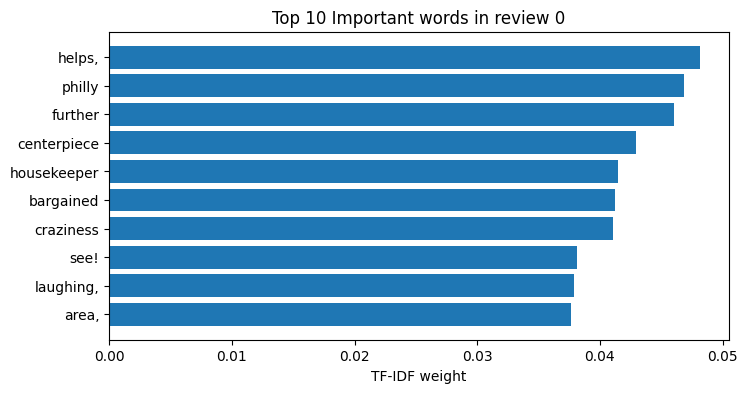

In [20]:
idx_to_word = {v:k for k,v in vocab.items()}

idx = 0 # change num for different review
print(X_train[idx])
row = X_train_tfidf[idx]
print("word : wieght")
for i,v in enumerate(row):
        if v > 0:
            print(idx_to_word[i], " : ", v)

row = X_train_tfidf[idx]

# top 10 words
top = 10
top_idx = np.argsort(row)[-1*top:]
top_words = [idx_to_word[i] for i in top_idx]
top_vals = row[top_idx]

plt.figure(figsize=(8,4))
plt.barh(top_words, top_vals)
plt.xlabel("TF-IDF weight")
plt.title(f"Top 10 Important words in review {idx}")
plt.show()

## SVD

In [21]:
start = time.time()

k = 100

U, S, Vt = svds(X_train_tfidf, k=k)

X_reduced = U[:, :k].dot(np.diag(S[:k]))

svd_time = time.time() - start

print("Reduced shape:", X_reduced.shape)

Reduced shape: (40000, 100)


## CLustering

In [22]:
def init_centroids(
    X: np.ndarray,
    K: int,
    seed: int,
) -> np.ndarray:
    np.random.seed(seed=seed)

    N, d = X.shape
    c = None
    
    c = np.zeros((K,d))
    idx = np.random.randint(N)
    c[0] = X[idx]

    for k in range(1, K):
        dist_sq = np.min(np.sum((X[:, None] - c[:k]) ** 2, axis=2), axis=1)
        total = np.sum(dist_sq)

        if total == 0:
            idx = np.random.randint(N)
        else:
            prob = dist_sq / total
            idx = np.random.choice(N, p=prob)
        c[k] = X[idx]
    return c

In [23]:

def assign_clusters(X: np.ndarray, C: np.ndarray) -> np.ndarray:
    z = None
    dist_sq = np.sum((X[:, None] - C) ** 2, axis=2)
    z = np.argmin(dist_sq, axis=1)

    return z

In [24]:

def update_centroids(
    X: np.ndarray,
    z: np.ndarray,
    K: int,
    seed: int = 0,
) -> np.ndarray:
    np.random.seed(seed=seed)
    N, d = X.shape
    c_new = np.zeros((K,d))

    for k in range(K):
        points = X[z == k]

        if len(points) == 0:
            idx = np.random.randint(0, N)
            c_new[k] = X[idx]
        else:
            c_new[k] = np.mean(points, axis=0)
    return c_new

In [25]:
def kmeans(
    X: np.ndarray,
    K: int,
    seed: int,
    max_iters: int = 100,
    tol: float = 1e-6,
) -> dict:
    c = init_centroids(X, K, seed)

    history = []
    z = None
    J = None

    for i in range(max_iters):
        z = assign_clusters(X,c)

        dist_sq = np.sum((X - c[z])**2, axis=1)
        J = np.sum(dist_sq)
        history.append(J)

        c_new = update_centroids(X, z, K, seed)

        shift = np.linalg.norm(c_new - c)
        c = c_new

        if shift < tol:
            break
    
    z = assign_clusters(X, c)
    dist_sq = np.sum((X - c[z])**2, axis=1)
    J = np.sum(dist_sq)

    return{
        "centroids": c,
        "labels": z,
        "inertia": J,
        "history": history,
    }

In [26]:
start = time.time()

result = kmeans(X_reduced, K=2, seed=42)

end_train = time.time() - start

labels = result["labels"]
centroids = result["centroids"]
history = result["history"]

print("Final inertia:", result["inertia"])
print("Cluster counts:")
for k in range(5):
    print(k, np.sum(labels == k))



Final inertia: 224.3133919376885
Cluster counts:
0 18855
1 21145
2 0
3 0
4 0


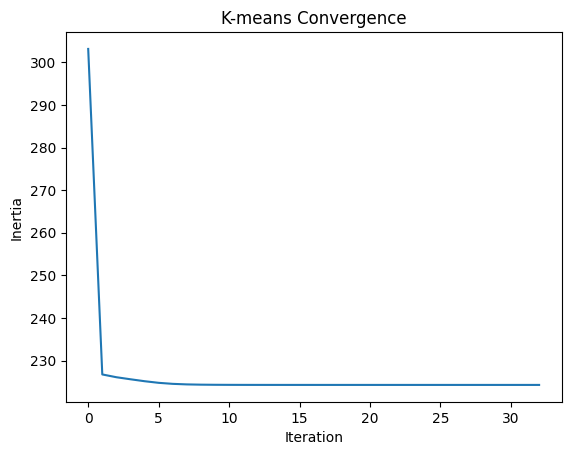

In [27]:
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Inertia")
plt.title("K-means Convergence")
plt.show()

In [28]:
def cluster_to_label_map(cluster_labels, y_true, K):

    mapping = {}

    for k in range(K):
        idx = np.where(cluster_labels == k)[0]

        if len(idx) == 0:
            mapping[k] = 0
        else:
            majority = np.round(np.mean(y_true[idx]))
            mapping[k] = int(majority)

    return mapping

In [29]:
def predict_cluster(X, centroids):

    dist_sq = np.sum((X[:, None] - centroids)**2, axis=2)

    labels = np.argmin(dist_sq, axis=1)

    return labels

In [30]:
def cluster_predictions(cluster_labels, mapping):

    y_pred = np.array([mapping[z] for z in cluster_labels])

    return y_pred

In [31]:
def evaluate_clustering_model(X_test, y_test, centroids, mapping):

    cluster_labels = predict_cluster(X_test, centroids)

    y_pred = cluster_predictions(cluster_labels, mapping)

    metrics = evaluate_predictions(y_test, y_pred, model_name="KMeans")

    return metrics

In [32]:
centroids = result["centroids"]
train_clusters = result["labels"]
mapping = cluster_to_label_map(train_clusters, y_train, K=2)

In [33]:
X_test_reduced = X_test_tfidf.dot(Vt.T)

start = time.time()
pred_eval = evaluate_clustering_model(
    X_test_reduced,
    y_test,
    centroids,
    mapping
)

ent_test = time.time() - start

In [34]:
print(f"\n===== {pred_eval["model"]} =====")
print(f"Weighting time: {TF_idf_time}")
print(f"Train Time: {end_train}")
print(f"Test Time: {ent_test}")
print(f"Accuracy : {pred_eval["accuracy"]:.4f}")
print(f"Precision: {pred_eval["precision"]:.4f}")
print(f"Recall   : {pred_eval["recall"]:.4f}")
print(f"F1-score : {pred_eval["f1"]:.4f}")



===== KMeans =====
Weighting time: 9.688241004943848
Train Time: 0.6685981750488281
Test Time: 0.0025141239166259766
Accuracy : 0.6174
Precision: 0.6110
Recall   : 0.6460
F1-score : 0.6280


## Demo

In [35]:
def sentence_to_tfidf(sentence, vocab, idf):
    words = tokenize(sentence)
    vec = np.zeros(len(vocab), dtype=np.float32)

    # term frequency for single sentence
    for w in words:
        if w in vocab:
            j = vocab[w]
            vec[j] += 1

    if len(words) > 0:
        vec = vec / len(words)

    vec = vec * idf
    return vec


def predict_sentence_clustering(sentence):
    # sentence -> tfidf
    vec = sentence_to_tfidf(sentence, vocab, idf)

    # tfidf -> reduced space using train SVD basis
    x_reduced = vec.dot(Vt.T)   # shape: (k,)

    # nearest centroid
    dist_sq = np.sum((centroids - x_reduced) ** 2, axis=1)
    cluster = np.argmin(dist_sq)

    # cluster -> sentiment label
    pred = mapping[cluster]

    label = "Positive" if pred == 1 else "Negative"
    return label, cluster


while True:
    text = input("Enter a review (type 'quit' to stop): ")

    if text.lower() == "quit":
        break

    label, cluster = predict_sentence_clustering(text)
    print(f"Input: {text}")
    print(f"Prediction: {label}")
    print(f"Cluster: {cluster}\n")